In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
from statistics import stdev
from scipy.stats import t
import warnings
warnings.filterwarnings('ignore')

/Users/ratikpant/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv('/Users/ratikpant/Desktop/QUANTIUM PROJECT/merged_data.csv')


In [3]:
df

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,MONTH,YEAR,DAY,total_spend,monthly_sales,product_Bought,price_per_product,PACK_SIZE,pack_size_num
0,1000,YOUNG SINGLES/COUPLES,Premium,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,10,2018,17,6.0,164409.7,2,3.0,175g,175
1,1002,YOUNG SINGLES/COUPLES,Mainstream,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,9,2018,16,2.7,160522.0,1,2.7,150g,150
2,1003,YOUNG FAMILIES,Budget,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,3,2019,7,6.6,166265.2,2,3.6,210G,210
3,1003,YOUNG FAMILIES,Budget,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,3,2019,8,6.6,166265.2,2,3.0,175g,175
4,1004,OLDER SINGLES/COUPLES,Mainstream,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,11,2018,2,1.9,160233.7,1,1.9,160g,160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264828,2370701,YOUNG FAMILIES,Mainstream,2018-12-08,88,240378,24,Grain Waves Sweet Chilli 210g,2,7.2,12,2018,8,7.2,167913.4,2,3.6,210g,210
264829,2370751,YOUNG FAMILIES,Premium,2018-10-01,88,240394,60,Kettle Tortilla ChpsFeta&Garlic 150g,2,9.2,10,2018,1,9.2,164409.7,2,4.6,150g,150
264830,2370961,OLDER FAMILIES,Budget,2018-10-24,88,240480,70,Tyrrells Crisps Lightly Salted 165g,2,8.4,10,2018,24,18.6,164409.7,4,4.2,165g,165
264831,2370961,OLDER FAMILIES,Budget,2018-10-27,88,240481,65,Old El Paso Salsa Dip Chnky Tom Ht300g,2,10.2,10,2018,27,18.6,164409.7,4,5.1,300g,300


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264833 entries, 0 to 264832
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   LYLTY_CARD_NBR     264833 non-null  int64  
 1   LIFESTAGE          264833 non-null  object 
 2   PREMIUM_CUSTOMER   264833 non-null  object 
 3   DATE               264833 non-null  object 
 4   STORE_NBR          264833 non-null  int64  
 5   TXN_ID             264833 non-null  int64  
 6   PROD_NBR           264833 non-null  int64  
 7   PROD_NAME          264833 non-null  object 
 8   PROD_QTY           264833 non-null  int64  
 9   TOT_SALES          264833 non-null  float64
 10  MONTH              264833 non-null  int64  
 11  YEAR               264833 non-null  int64  
 12  DAY                264833 non-null  int64  
 13  total_spend        264833 non-null  float64
 14  monthly_sales      264833 non-null  float64
 15  product_Bought     264833 non-null  int64  
 16  pr

In [5]:
df_copy = df.copy()

# storing new trial layout stores in a separate dataframe.

In [6]:
trial_stores = df[df['STORE_NBR'].isin([77, 86, 88])]

# other than the new layout stores dataframe

In [7]:
df = df[~df['STORE_NBR'].isin([77, 86, 88])]

In [8]:
df

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,MONTH,YEAR,DAY,total_spend,monthly_sales,product_Bought,price_per_product,PACK_SIZE,pack_size_num
0,1000,YOUNG SINGLES/COUPLES,Premium,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,10,2018,17,6.0,164409.7,2,3.0,175g,175
1,1002,YOUNG SINGLES/COUPLES,Mainstream,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,9,2018,16,2.7,160522.0,1,2.7,150g,150
2,1003,YOUNG FAMILIES,Budget,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,3,2019,7,6.6,166265.2,2,3.6,210G,210
3,1003,YOUNG FAMILIES,Budget,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,3,2019,8,6.6,166265.2,2,3.0,175g,175
4,1004,OLDER SINGLES/COUPLES,Mainstream,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,11,2018,2,1.9,160233.7,1,1.9,160g,160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264797,880711,OLDER FAMILIES,Budget,2018-09-04,237,86566,31,Infzns Crn Crnchers Tangy Gcamole 110g,2,7.6,9,2018,4,16.8,160522.0,4,3.8,110g,110
264798,880711,OLDER FAMILIES,Budget,2018-09-15,237,86567,3,Kettle Sensations Camembert & Fig 150g,2,9.2,9,2018,15,16.8,160522.0,4,4.6,150g,150
264799,883791,OLDER SINGLES/COUPLES,Mainstream,2018-09-12,237,88099,87,Infuzions BBQ Rib Prawn Crackers 110g,2,7.6,9,2018,12,22.6,160522.0,6,3.8,110g,110
264800,883791,OLDER SINGLES/COUPLES,Mainstream,2018-09-29,237,88100,33,Cobs Popd Swt/Chlli &Sr/Cream Chips 110g,2,7.6,9,2018,29,22.6,160522.0,6,3.8,110g,110


In [9]:
trial_stores.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3974 entries, 73365 to 264832
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LYLTY_CARD_NBR     3974 non-null   int64  
 1   LIFESTAGE          3974 non-null   object 
 2   PREMIUM_CUSTOMER   3974 non-null   object 
 3   DATE               3974 non-null   object 
 4   STORE_NBR          3974 non-null   int64  
 5   TXN_ID             3974 non-null   int64  
 6   PROD_NBR           3974 non-null   int64  
 7   PROD_NAME          3974 non-null   object 
 8   PROD_QTY           3974 non-null   int64  
 9   TOT_SALES          3974 non-null   float64
 10  MONTH              3974 non-null   int64  
 11  YEAR               3974 non-null   int64  
 12  DAY                3974 non-null   int64  
 13  total_spend        3974 non-null   float64
 14  monthly_sales      3974 non-null   float64
 15  product_Bought     3974 non-null   int64  
 16  price_per_product  3974

In [10]:
#LETS CHANGE THE DATE INTO DATETIME

In [11]:
trial_stores['DATE'] = pd.to_datetime(trial_stores['DATE'])

In [12]:
#LETS EXTRACT YEAR MONTH AND CONVERT THEM INTO timestamp FOR CHRONOLOGICALLY PLOTTING

In [13]:
trial_stores['year_month'] = trial_stores['DATE'].dt.to_period('M')

In [14]:
trial_stores['year_month'] = trial_stores['year_month'].dt.to_timestamp()

In [15]:
#CALCULATE THE MONTHLY SALES FOR NEW TRIAL STORES 77, 86, 88

In [16]:
trial_sales = trial_stores.groupby(['year_month', 'STORE_NBR'])['TOT_SALES'].sum().reset_index()
trial_sales

,year_month,STORE_NBR,TOT_SALES
0,2018-07-01,77,296.80
1,2018-07-01,86,892.20
2,2018-07-01,88,1310.00
3,2018-08-01,77,255.50
4,2018-08-01,86,764.05
5,2018-08-01,88,1323.80
6,2018-09-01,77,225.20
7,2018-09-01,86,914.60
8,2018-09-01,88,1423.00
9,2018-10-01,77,204.50


In [17]:
pivot_df = trial_sales.pivot(index= 'year_month', columns='STORE_NBR', values='TOT_SALES')
pivot_df

STORE_NBR,77,86,88
year_month,,,
2018-07-01,296.8,892.20,1310.00
2018-08-01,255.5,764.05,1323.80
2018-09-01,225.2,914.60,1423.00
2018-10-01,204.5,948.40,1352.40
2018-11-01,245.3,918.00,1382.80
2018-12-01,267.3,841.20,1325.20
2019-01-01,204.4,841.40,1266.40
2019-02-01,235.0,913.20,1370.20
2019-03-01,278.5,1026.80,1477.20


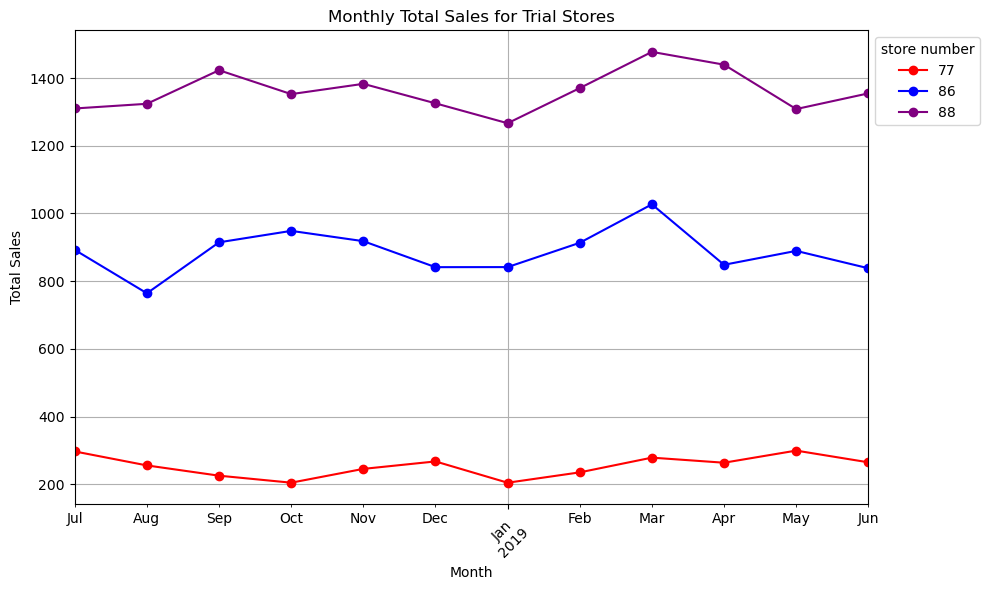

In [18]:
color = ['red', 'blue', 'purple']
pivot_df.plot(marker='o', color = color,figsize = (10,6))
plt.title('Monthly Total Sales for Trial Stores')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.legend(title = 'store number', bbox_to_anchor = (1,1))
plt.grid(True)
plt.tight_layout()
plt.show()    

# as the trial period was feb 2019 until april 2019 we definetly see an spike in sales during that period for store 77, 86, 88.

# CALCULATING the cumulative sales and seeing if we get to see a trend

In [19]:
#converting it back into period

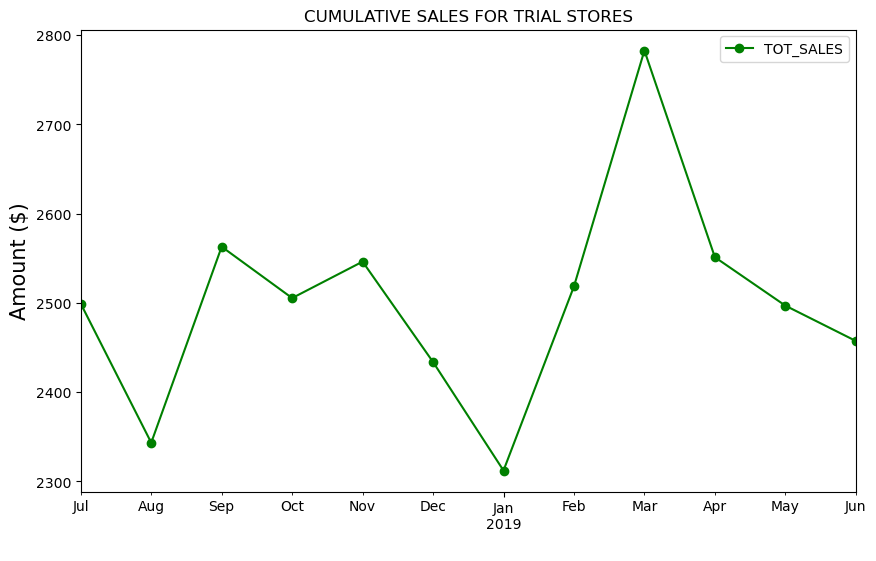

In [20]:
cumulative_sales = trial_stores.groupby(['year_month'])['TOT_SALES'].sum().reset_index()
cumulative_sales.plot(x = 'year_month', y = 'TOT_SALES',color = 'green', marker = 'o',figsize = (10,6),
                      title ="CUMULATIVE SALES FOR TRIAL STORES")
plt.xlabel(" ")
plt.ylabel("Amount ($)", fontsize =15)
plt.show()
                     

In [21]:
#FOOTFALL FOR TRIAL STORES

In [22]:
trial_stores.drop(columns = {'monthly_sales'},inplace = True)

In [23]:
footfall = trial_stores.groupby(['year_month', 'STORE_NBR'])['LYLTY_CARD_NBR'].nunique().reset_index()
footfall

,year_month,STORE_NBR,LYLTY_CARD_NBR
0,2018-07-01,77,51
1,2018-07-01,86,99
2,2018-07-01,88,129
3,2018-08-01,77,47
4,2018-08-01,86,94
5,2018-08-01,88,131
6,2018-09-01,77,42
7,2018-09-01,86,103
8,2018-09-01,88,124
9,2018-10-01,77,37


In [24]:
footfall_pivot = footfall.pivot(index = 'year_month', columns = 'STORE_NBR', values = 'LYLTY_CARD_NBR' )
footfall_pivot

STORE_NBR,77,86,88
year_month,,,
2018-07-01,51,99,129
2018-08-01,47,94,131
2018-09-01,42,103,124
2018-10-01,37,109,123
2018-11-01,41,100,130
2018-12-01,46,98,126
2019-01-01,35,94,117
2019-02-01,45,107,124
2019-03-01,50,115,134


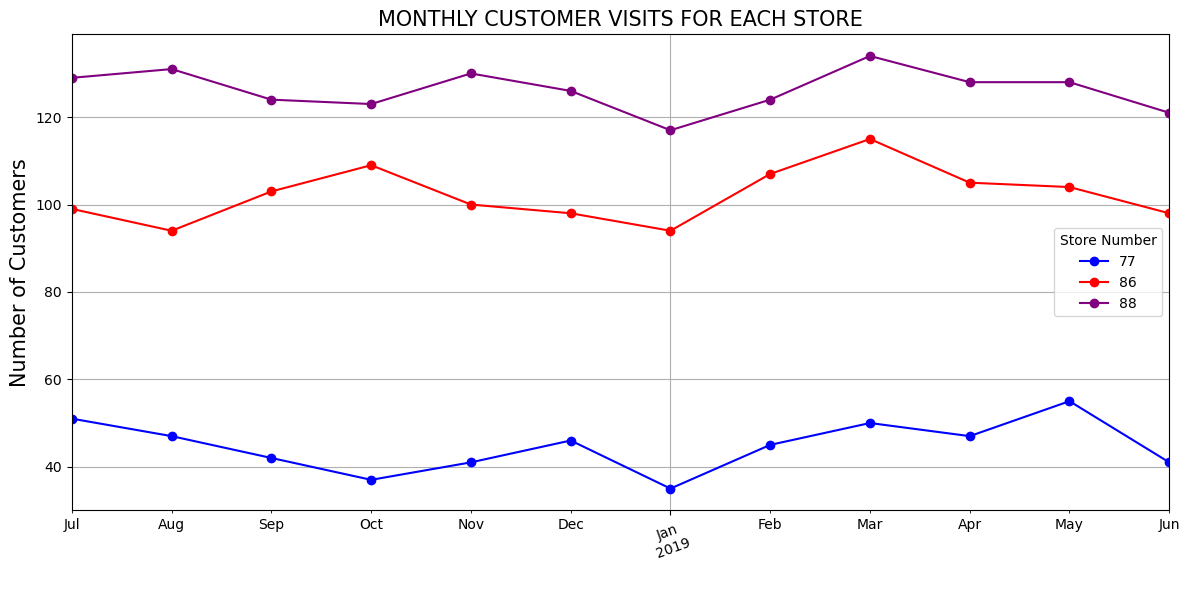

In [25]:
color = ['blue', 'red', 'purple']
footfall_pivot.plot(marker='o', figsize=(12, 6), color = color)
plt.title("MONTHLY CUSTOMER VISITS FOR EACH STORE", fontsize =15)
plt.xlabel(" ")
plt.ylabel("Number of Customers",fontsize =15)  
plt.grid(True)
plt.legend(title='Store Number')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

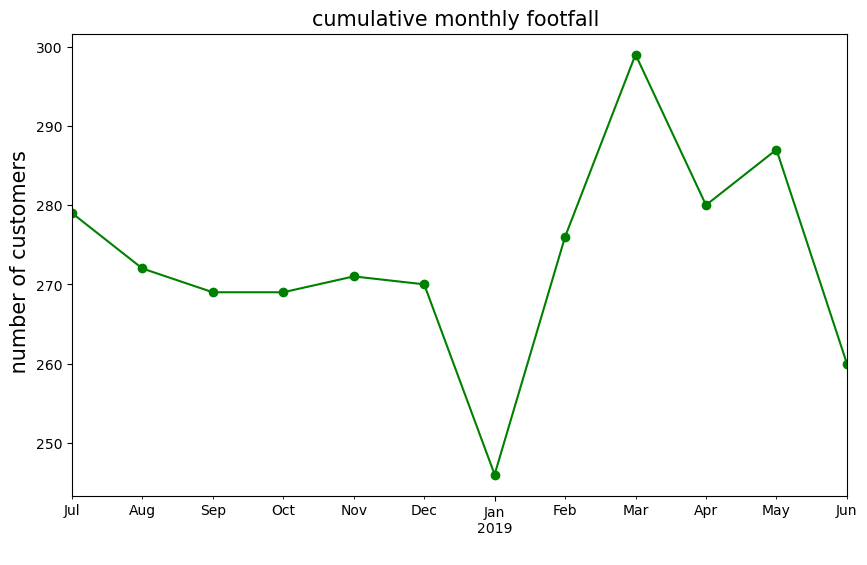

In [26]:
cumulative_footfall = trial_stores.groupby(['year_month'])['LYLTY_CARD_NBR'].nunique()
cumulative_footfall.plot(x = 'year_month', y = 'LYLTY_CARD_NBR', figsize = (10,6), marker ='o', color = 'green')
plt.title("cumulative monthly footfall ",fontsize =15)
plt.xlabel(" ")
plt.ylabel(" number of customers", fontsize =15)
plt.show()

In [27]:
# we definetly identify a pattern here that trial stores did see some sort of an elevation during the trial testing.

In [28]:
#lets check the 3rd driver which is avg transaction per store on a monthly basis.
# this is been done to see if we see a considerable uplift in no. of transactions.

In [29]:
#we change the year_month to date time from period.

In [30]:
count_transaction = trial_stores.groupby(['year_month', 'STORE_NBR'])['TXN_ID'].count().reset_index()


In [31]:
pivot_count = count_transaction.pivot(index = 'year_month', columns = 'STORE_NBR', values = 'TXN_ID')

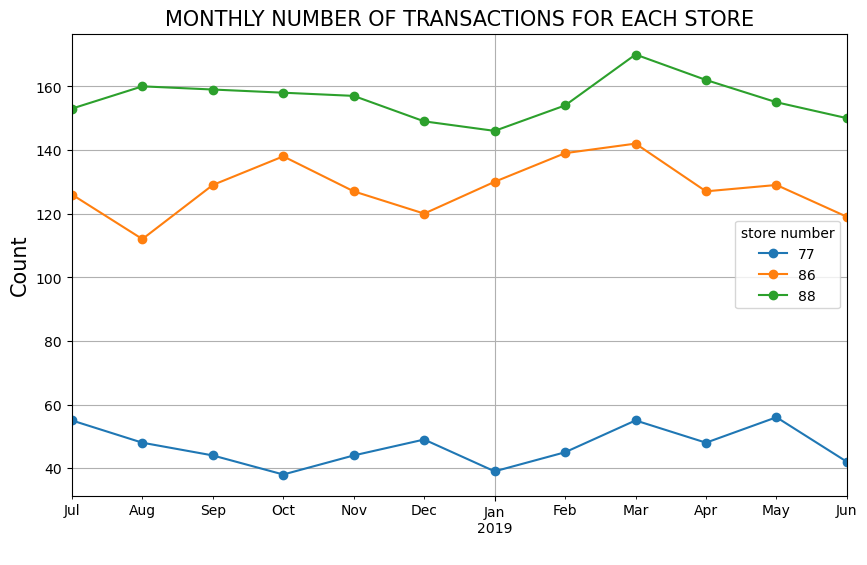

In [32]:
pivot_count.plot(marker = 'o', figsize = (10,6))
plt.title("MONTHLY NUMBER OF TRANSACTIONS FOR EACH STORE", fontsize =15)
plt.xlabel(" ")
plt.ylabel("Count", fontsize =15)
plt.grid(True)
plt.legend(title = 'store number')
plt.show()

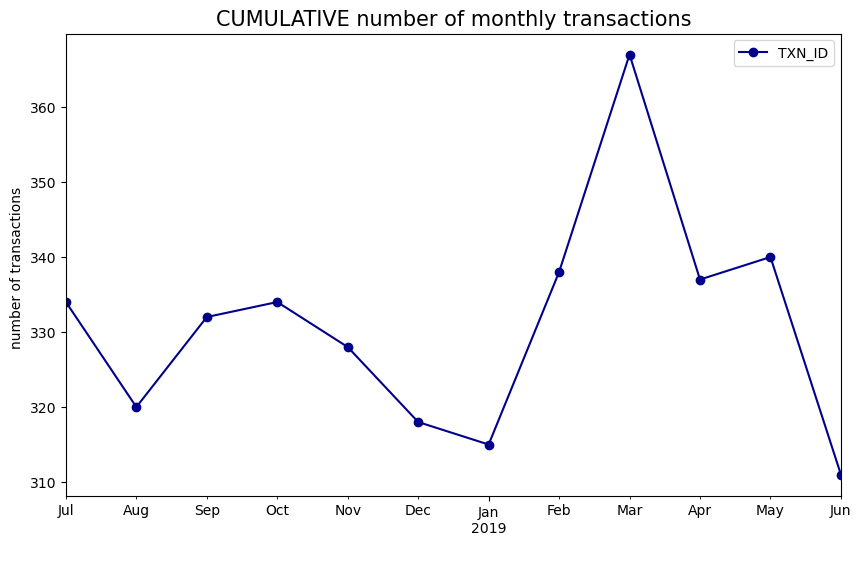

In [33]:
cumulative_count = trial_stores.groupby(['year_month'])['TXN_ID'].count().reset_index()
cumulative_count.plot(x = 'year_month', y = 'TXN_ID', figsize = (10,6), marker = 'o',color = 'darkblue')
plt.title("CUMULATIVE number of monthly transactions", fontsize =15)
plt.xlabel(" ")
plt.ylabel("number of transactions ")
plt.show()

# overview of the trial stores is done , and one can infer from all the different visuals above that there is
# definetly a traction brought by the 'specials' done during feb 2019 - april 2019 

In [34]:
#Now lets select control stores(similiar stores)

In [35]:
#let's calculate the measures for pre trial period monthly 1) total sales, no. of customers, no. of txn

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 260859 entries, 0 to 264801
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   LYLTY_CARD_NBR     260859 non-null  int64  
 1   LIFESTAGE          260859 non-null  object 
 2   PREMIUM_CUSTOMER   260859 non-null  object 
 3   DATE               260859 non-null  object 
 4   STORE_NBR          260859 non-null  int64  
 5   TXN_ID             260859 non-null  int64  
 6   PROD_NBR           260859 non-null  int64  
 7   PROD_NAME          260859 non-null  object 
 8   PROD_QTY           260859 non-null  int64  
 9   TOT_SALES          260859 non-null  float64
 10  MONTH              260859 non-null  int64  
 11  YEAR               260859 non-null  int64  
 12  DAY                260859 non-null  int64  
 13  total_spend        260859 non-null  float64
 14  monthly_sales      260859 non-null  float64
 15  product_Bought     260859 non-null  int64  
 16  price_p

In [37]:
#converting data type into time

In [38]:
df['DATE']= pd.to_datetime(df['DATE'])

In [39]:
df['year_month'] = df['DATE'].dt.to_period('M')

In [40]:
df['year_month'] = df['year_month'].dt.to_timestamp()

In [41]:
#calculating the sales drivers

In [42]:
control_store_metrics = df.groupby(['STORE_NBR', 'year_month']).agg(
    total_Monthly_Sales=('TOT_SALES', 'sum'),
    no_of_monthly_Customers=('LYLTY_CARD_NBR', 'nunique'),
    no_of_monthly_Txn=('TXN_ID', 'nunique')
).reset_index()

In [43]:
control_store_metrics['avg_trns_per_cust'] = control_store_metrics['no_of_monthly_Txn'] / control_store_metrics['no_of_monthly_Customers']

In [44]:
control_store_metrics

,STORE_NBR,year_month,total_Monthly_Sales,no_of_monthly_Customers,no_of_monthly_Txn,avg_trns_per_cust
0,1,2018-07-01,206.9,49,52,1.061224
1,1,2018-08-01,176.1,42,43,1.023810
2,1,2018-09-01,278.8,59,62,1.050847
3,1,2018-10-01,188.1,44,45,1.022727
4,1,2018-11-01,192.6,46,47,1.021739
...,...,...,...,...,...,...
3128,272,2019-02-01,395.5,45,48,1.066667
3129,272,2019-03-01,442.3,50,53,1.060000
3130,272,2019-04-01,445.1,54,55,1.018519
3131,272,2019-05-01,314.6,34,40,1.176471


In [45]:
#for that first we will filter stores pre-trial-period

In [46]:
pre_trial_control_store = control_store_metrics[control_store_metrics['year_month'] < '2019-02-01']

In [47]:
pre_trial_control_store

,STORE_NBR,year_month,total_Monthly_Sales,no_of_monthly_Customers,no_of_monthly_Txn,avg_trns_per_cust
0,1,2018-07-01,206.9,49,52,1.061224
1,1,2018-08-01,176.1,42,43,1.023810
2,1,2018-09-01,278.8,59,62,1.050847
3,1,2018-10-01,188.1,44,45,1.022727
4,1,2018-11-01,192.6,46,47,1.021739
...,...,...,...,...,...,...
3123,272,2018-09-01,304.7,32,36,1.125000
3124,272,2018-10-01,430.6,44,50,1.136364
3125,272,2018-11-01,376.2,41,45,1.097561
3126,272,2018-12-01,403.9,47,47,1.000000


In [48]:
trial_stores_metric = trial_stores.groupby(['year_month','STORE_NBR']).agg(
Total_Monthly_Sales=('TOT_SALES', 'sum'),
    no_of_monthly_Customers=('LYLTY_CARD_NBR', 'nunique'),
    no_of_monthly_Txn=('TXN_ID', 'nunique')
).reset_index()

In [49]:
trial_stores_metric['avg_trns_per_cst'] = trial_stores_metric['no_of_monthly_Txn'] / trial_stores_metric['no_of_monthly_Customers']

In [50]:
pre_trial_stores_metric = trial_stores_metric[trial_stores_metric['year_month'] < '2019-02-01']

In [51]:
pre_trial_stores_metric

,year_month,STORE_NBR,Total_Monthly_Sales,no_of_monthly_Customers,no_of_monthly_Txn,avg_trns_per_cst
0,2018-07-01,77,296.80,51,55,1.078431
1,2018-07-01,86,892.20,99,126,1.272727
2,2018-07-01,88,1310.00,129,153,1.186047
3,2018-08-01,77,255.50,47,48,1.021277
4,2018-08-01,86,764.05,94,110,1.170213
5,2018-08-01,88,1323.80,131,158,1.206107
6,2018-09-01,77,225.20,42,44,1.047619
7,2018-09-01,86,914.60,103,128,1.242718
8,2018-09-01,88,1423.00,124,157,1.266129
9,2018-10-01,77,204.50,37,38,1.027027


In [52]:
pre_trial_control_store = pre_trial_control_store.rename(columns = {'total_Monthly_Sales' : 'Total_Monthly_Sales'})

In [53]:
#WE WILL DEFINE A FUNCTION AND FIND THE SIMILARITY USING eucledian distance & correlation

In [54]:
def calculate_correlation(metric_df, metric_col, trial_series):
    corr_results = []
    for store in metric_df['STORE_NBR'].unique():
        store_series = metric_df[metric_df['STORE_NBR'] == store][metric_col].reset_index(drop=True)
        if len(store_series) == len(trial_series):
            corr = trial_series.corr(store_series)
            corr_results.append({'Store2': store, 'corr_measure': corr})
    return pd.DataFrame(corr_results)

In [55]:
def calculate_magnitude(metric_df, metric_col, trial_series):
    mag_results = []
    for store in metric_df['STORE_NBR'].unique():
        store_series = metric_df[metric_df['STORE_NBR'] == store][metric_col].reset_index(drop=True)
        if len(store_series) == len(trial_series):
            dist = abs(trial_series - store_series)
            standardized = 1 - ((dist - dist.min()) / (dist.max() - dist.min()))
            mag_results.append({'Store2': store, 'mag_measure': standardized.mean()})
    return pd.DataFrame(mag_results)

In [56]:
def find_best_control_store(trial_df, control_df, trial_store):
    # Get trial store's data
    trial_data = trial_df[trial_df['STORE_NBR'] == trial_store]
    
    # Control data is already passed in
    control_data = control_df.copy()

    # Prepare trial store time series
    trial_sales_series = trial_data.sort_values('year_month')['Total_Monthly_Sales'].reset_index(drop=True)
    trial_customers_series = trial_data.sort_values('year_month')['no_of_monthly_Customers'].reset_index(drop=True)

    # Correlation
    corr_sales = calculate_correlation(control_data, 'Total_Monthly_Sales', trial_sales_series)
    corr_customers = calculate_correlation(control_data, 'no_of_monthly_Customers', trial_customers_series)

    # Magnitude
    mag_sales = calculate_magnitude(control_data, 'Total_Monthly_Sales', trial_sales_series)
    mag_customers = calculate_magnitude(control_data, 'no_of_monthly_Customers', trial_customers_series)

    # Combine scores
    score_sales = pd.merge(corr_sales, mag_sales, on='Store2')
    score_sales['scoreNSales'] = 0.5 * score_sales['corr_measure'] + 0.5 * score_sales['mag_measure']

    score_customers = pd.merge(corr_customers, mag_customers, on='Store2')
    score_customers['scoreNCust'] = 0.5 * score_customers['corr_measure'] + 0.5 * score_customers['mag_measure']

    control_score = pd.merge(score_sales[['Store2', 'scoreNSales']],
                             score_customers[['Store2', 'scoreNCust']],
                             on='Store2')

    control_score['finalControlScore'] = 0.5 * control_score['scoreNSales'] + 0.5 * control_score['scoreNCust']

    best_match = control_score.sort_values('finalControlScore', ascending=False).head(1)

    return best_match

In [57]:
control_77 = find_best_control_store(pre_trial_stores_metric, pre_trial_control_store, 77)

In [58]:
control_77

,Store2,scoreNSales,scoreNCust,finalControlScore
218,233,0.69729,0.816607,0.756949


In [59]:
#the original dataset's copy is  df_copy we will transoform the dataframe that matches our purpose

In [60]:
df_copy['DATE'] = pd.to_datetime(df_copy['DATE'])

In [61]:
df_copy['year_month'] = df_copy['DATE'].dt.to_period('M')

In [62]:
df_copy['year_month'] = df_copy['year_month'].dt.to_timestamp()

In [63]:
df_copy = df_copy.groupby(['year_month','STORE_NBR']).agg(
Total_Monthly_Sales=('TOT_SALES', 'sum'),
    no_of_monthly_Customers=('LYLTY_CARD_NBR', 'nunique'),
    no_of_monthly_Txn=('TXN_ID', 'nunique')
).reset_index()

In [64]:
df_copy['avg_trns_per_cust'] = df_copy['no_of_monthly_Txn'] / df_copy['no_of_monthly_Customers']

In [65]:
df_copy

,year_month,STORE_NBR,Total_Monthly_Sales,no_of_monthly_Customers,no_of_monthly_Txn,avg_trns_per_cust
0,2018-07-01,1,206.9,49,52,1.061224
1,2018-07-01,2,150.8,39,41,1.051282
2,2018-07-01,3,1205.7,112,138,1.232143
3,2018-07-01,4,1399.9,128,158,1.234375
4,2018-07-01,5,812.0,93,120,1.290323
...,...,...,...,...,...,...
3164,2019-06-01,268,224.7,38,40,1.052632
3165,2019-06-01,269,864.4,99,127,1.282828
3166,2019-06-01,270,912.2,104,127,1.221154
3167,2019-06-01,271,928.2,108,129,1.194444


# After finding out the closest match for trial store 77 , let's look patterns and trends.

In [66]:
trial_store = 77
control_store = 233

# Start from the full monthly metrics (pre + post)
measureOverTimeSales = df_copy.copy()

# Create store type column
measureOverTimeSales['Store_type'] = measureOverTimeSales['STORE_NBR'].apply(
    lambda x: 'Trial' if x == trial_store else ('Control' if x == control_store else 'Other stores')
)

In [67]:
pastSales = (
    measureOverTimeSales[measureOverTimeSales['year_month'] < '2019-02-01']
    .groupby(['year_month', 'Store_type'])['Total_Monthly_Sales']
    .mean()
    .reset_index()
)

In [68]:
pastSales = pastSales.pivot(index = 'year_month', columns = 'Store_type', values = 'Total_Monthly_Sales')

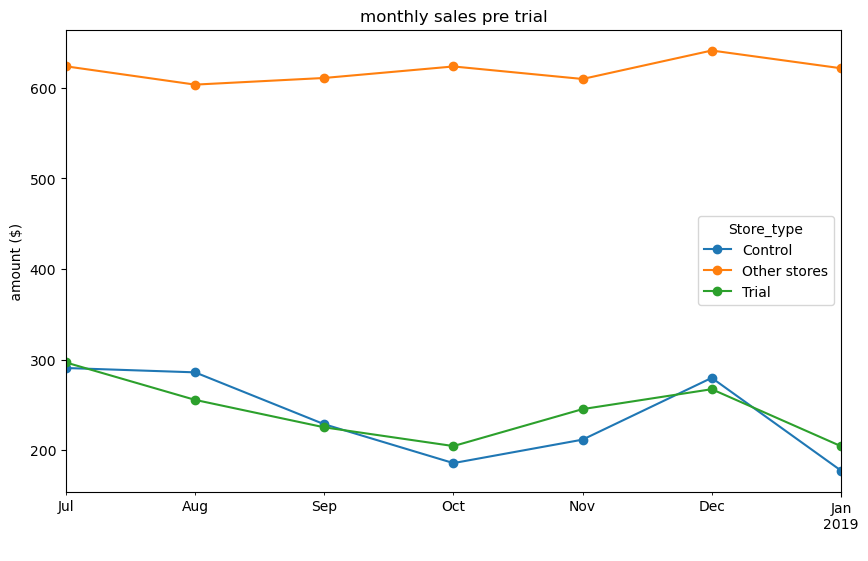

In [69]:
pastSales.plot(marker = 'o', figsize = (10,6))
plt.title('monthly sales pre trial')
plt.xlabel(" ")
plt.ylabel(" amount ($) ")
plt.show()

In [70]:
trial_comparison = (measureOverTimeSales[measureOverTimeSales['year_month'] > '2019-01-01']
    .groupby(['year_month', 'Store_type'])['Total_Monthly_Sales']
    .mean()
    .reset_index()
                   )

In [71]:
trial_comparison = trial_comparison.pivot(index = 'year_month', columns = 'Store_type', values = 'Total_Monthly_Sales')

Text(0, 0.5, ' amount ($) ')

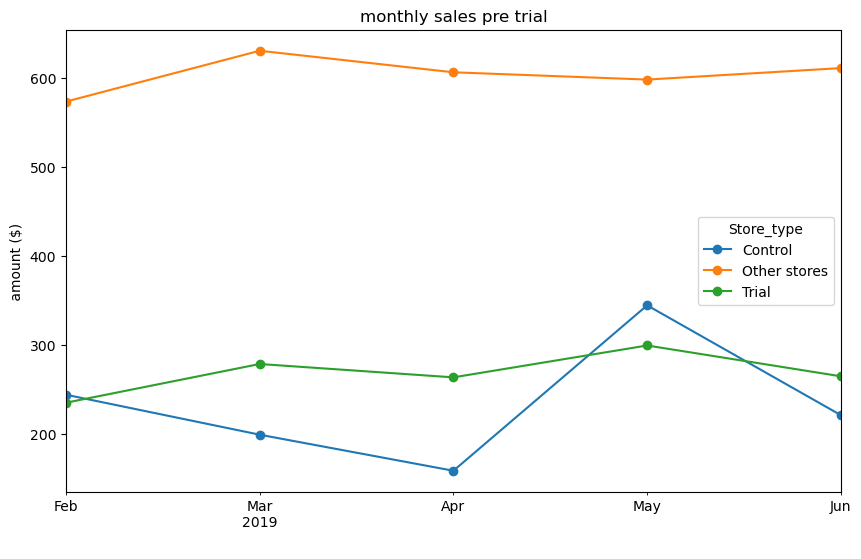

In [72]:
trial_comparison.plot(marker = 'o', figsize = (10,6))
plt.title('monthly sales pre trial')
plt.xlabel(" ")
plt.ylabel(" amount ($) ")

# the trend definetly shows that during the trial period the control store chips sale fell where as trial did had an effect on sales.

In [73]:
measureOverTimeSales

,year_month,STORE_NBR,Total_Monthly_Sales,no_of_monthly_Customers,no_of_monthly_Txn,avg_trns_per_cust,Store_type
0,2018-07-01,1,206.9,49,52,1.061224,Other stores
1,2018-07-01,2,150.8,39,41,1.051282,Other stores
2,2018-07-01,3,1205.7,112,138,1.232143,Other stores
3,2018-07-01,4,1399.9,128,158,1.234375,Other stores
4,2018-07-01,5,812.0,93,120,1.290323,Other stores
...,...,...,...,...,...,...,...
3164,2019-06-01,268,224.7,38,40,1.052632,Other stores
3165,2019-06-01,269,864.4,99,127,1.282828,Other stores
3166,2019-06-01,270,912.2,104,127,1.221154,Other stores
3167,2019-06-01,271,928.2,108,129,1.194444,Other stores


# let's chcek if the trial brought in more number of customers month wise.

In [74]:
cust_comparison = (
    measureOverTimeSales[measureOverTimeSales['year_month'] > '2019-01-01'].groupby(
    ['Store_type', 'year_month'])['no_of_monthly_Customers'].mean().reset_index()
)
    

In [75]:
cust_comparison = cust_comparison.groupby(
    ['year_month', 'Store_type'])['no_of_monthly_Customers'].mean().reset_index()

In [76]:
cust_comparison = cust_comparison.pivot(index = 'year_month', columns = 'Store_type', values = 'no_of_monthly_Customers')

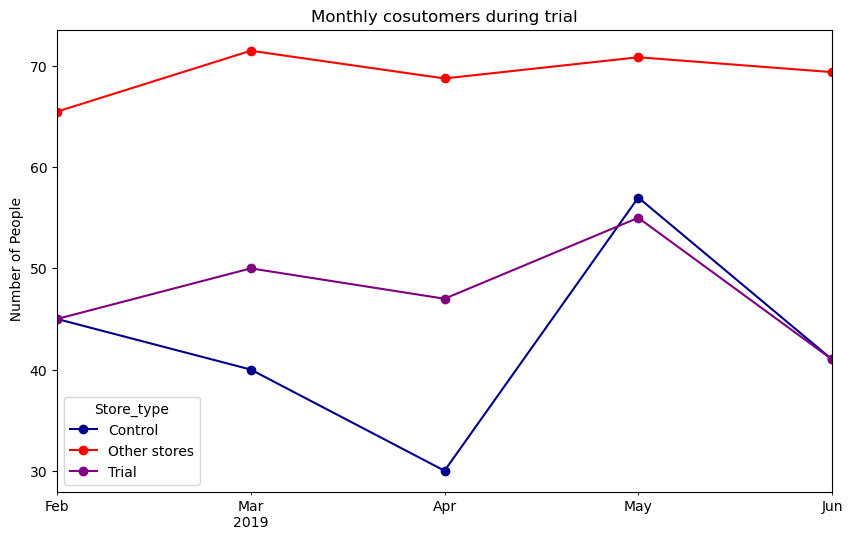

In [77]:
cust_comparison.plot(marker = 'o', color = ['darkblue', 'red','purple'], figsize = (10,6),title = "Monthly cosutomers during trial",
                    xlabel = (" "), ylabel = ("  Number of People "))
plt.show()

# we can surely see a difference in the number of customers during the trial period.

# Let's check if there is any statistican difference in sales number between first trial store and its control store.

In [78]:
trial_store = 77
control_store = 233
trial_store_data = measureOverTimeSales[measureOverTimeSales['STORE_NBR']== trial_store]
control_store_data = measureOverTimeSales[measureOverTimeSales['STORE_NBR']== control_store]

In [79]:
trial_store_number = trial_store_data[trial_store_data['year_month'] < '2019-02-01']['Total_Monthly_Sales'].sum()

In [80]:
control_sales = control_store_data[control_store_data['year_month'] < '2019-02-01']['Total_Monthly_Sales'].sum()

In [81]:
scaling_factor = trial_store_number / control_sales

# let's calculate the scaling factor to control sales data.

In [82]:
control_store_data['scaled_value'] = control_store_data['Total_Monthly_Sales'] * scaling_factor

In [83]:
control_store_data

,year_month,STORE_NBR,Total_Monthly_Sales,no_of_monthly_Customers,no_of_monthly_Txn,avg_trns_per_cust,Store_type,scaled_value
227,2018-07-01,233,290.7,51,54,1.058824,Control,297.565550
489,2018-08-01,233,285.9,48,50,1.041667,Control,292.652187
754,2018-09-01,233,228.6,42,45,1.071429,Control,233.998916
1019,2018-10-01,233,185.7,35,36,1.028571,Control,190.085733
1283,2018-11-01,233,211.6,40,41,1.025000,Control,216.597421
1546,2018-12-01,233,279.8,47,50,1.063830,Control,286.408121
1809,2019-01-01,233,177.5,35,35,1.000000,Control,181.692071
2073,2019-02-01,233,244.0,45,47,1.044444,Control,249.762622
2337,2019-03-01,233,199.1,40,41,1.025000,Control,203.802205
2603,2019-04-01,233,158.6,30,32,1.066667,Control,162.345704


# Merging the two dataframes with total sales 

In [84]:
merge_sales = pd.merge(trial_store_data[['year_month','Total_Monthly_Sales']],control_store_data[['year_month' ,'scaled_value']], 
                     on = 'year_month' )
                                                                                            

In [85]:
merge_sales

,year_month,Total_Monthly_Sales,scaled_value
0,2018-07-01,296.8,297.565550
1,2018-08-01,255.5,292.652187
2,2018-09-01,225.2,233.998916
3,2018-10-01,204.5,190.085733
4,2018-11-01,245.3,216.597421
5,2018-12-01,267.3,286.408121
6,2019-01-01,204.4,181.692071
7,2019-02-01,235.0,249.762622
8,2019-03-01,278.5,203.802205
9,2019-04-01,263.5,162.345704


# calculating absolute difference for calculating t value later on

In [86]:
merge_sales['percentageDiff'] = abs(
    merge_sales['Total_Monthly_Sales'] - merge_sales['scaled_value']
) / merge_sales['scaled_value']


In [87]:
merge_sales

,year_month,Total_Monthly_Sales,scaled_value,percentageDiff
0,2018-07-01,296.8,297.565550,0.002573
1,2018-08-01,255.5,292.652187,0.126950
2,2018-09-01,225.2,233.998916,0.037602
3,2018-10-01,204.5,190.085733,0.075830
4,2018-11-01,245.3,216.597421,0.132516
5,2018-12-01,267.3,286.408121,0.066716
6,2019-01-01,204.4,181.692071,0.124980
7,2019-02-01,235.0,249.762622,0.059107
8,2019-03-01,278.5,203.802205,0.366521
9,2019-04-01,263.5,162.345704,0.623080


# Lets calculate the standard deviation for  pre trial period

In [88]:
st_Dev = stdev(merge_sales.loc[merge_sales['year_month'] < '2019-02-01', 'percentageDiff'])

In [89]:
st_Dev

0.049940762641425364

# hypothesis testing - > there is  0 difference in trial period sales and pre trial period sales


In [90]:
merge_sales['tvalue'] = (merge_sales['percentageDiff'] - 0)/ st_Dev
merge_sales.loc[(merge_sales['year_month'] > '2019-01-01') & (merge_sales['year_month'] < '2019-05-01'), 'tvalue' ]

7     1.183534
8     7.339116
9    12.476373
Name: tvalue, dtype: float64

In [91]:
#LET'S CHECK THE T_THRESOLD VALUE

In [92]:
t_95  = t.isf(0.05, df = 7 )

In [93]:
t_95

1.8945786050613054

# We can observe that the t-value is much larger than the 95th percentile value of the t-distribution for March and April - i.e. the increase in sales in the trial store in March and April is statistically greater than in the control store.

In [94]:
merge_sales

,year_month,Total_Monthly_Sales,scaled_value,percentageDiff,tvalue
0,2018-07-01,296.8,297.565550,0.002573,0.051515
1,2018-08-01,255.5,292.652187,0.126950,2.542011
2,2018-09-01,225.2,233.998916,0.037602,0.752940
3,2018-10-01,204.5,190.085733,0.075830,1.518406
4,2018-11-01,245.3,216.597421,0.132516,2.653459
5,2018-12-01,267.3,286.408121,0.066716,1.335911
6,2019-01-01,204.4,181.692071,0.124980,2.502571
7,2019-02-01,235.0,249.762622,0.059107,1.183534
8,2019-03-01,278.5,203.802205,0.366521,7.339116
9,2019-04-01,263.5,162.345704,0.623080,12.476373


In [95]:
#let's visually check the results of trial store and control store.

In [96]:
plot_df = merge_sales[['year_month', 'Total_Monthly_Sales', 'scaled_value']].copy()
plot_df.rename(columns = {'Total_Monthly_Sales' : 'trial_store', 
                         'scaled_value' : 'control_Store'},inplace = True)

In [97]:
plot_df = plot_df.melt(id_vars = 'year_month', value_vars = ['trial_store', 'control_Store'], var_name = 'Store_type',
                  value_name = 'Sales')

In [98]:
plot_df['Sales'] = plot_df['Sales'] .round(2)

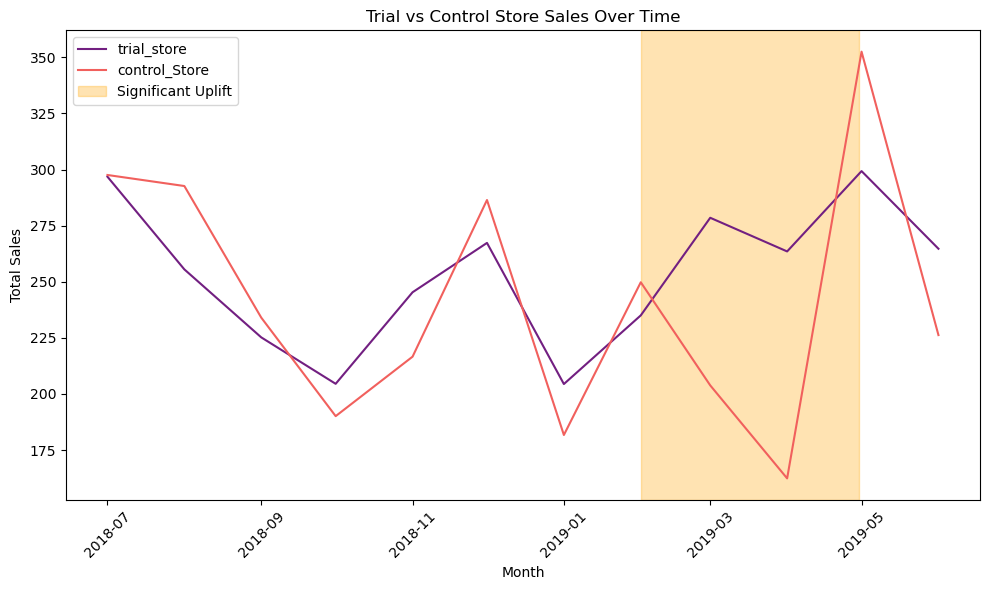

In [134]:
plt.figure(figsize =(10,6))
sns.lineplot(data = plot_df, x = 'year_month', y = 'Sales', hue = 'Store_type',palette = 'magma')
plt.axvspan(pd.to_datetime("2019-02-01"), pd.to_datetime("2019-04-30"), 
            color='orange', alpha=0.3, label='Significant Uplift')

plt.title('Trial vs Control Store Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# There is a definite uplift in sale in store number 77 compared to its twin store, which means the campaign ran in the stores did pull larger number in sales of chips. We reject the null hypothesis and say there is a statistical significance in sales of the store.

# Now lets do it for trial store 86 and compare the sales and check if the sales during the promotional period was statistically significant

In [100]:
trial_store = 86
trial_df = pre_trial_stores_metric
control_df = pre_trial_control_store

In [101]:
control_86 = find_best_control_store(trial_df, control_df, trial_store)

In [102]:
control_86

,Store2,scoreNSales,scoreNCust,finalControlScore
144,155,0.808106,0.733343,0.770724


In [103]:
trial_86 =pre_trial_stores_metric[pre_trial_stores_metric['STORE_NBR'] == 86 ]

In [104]:
controll_86 = pre_trial_control_store[pre_trial_control_store['STORE_NBR'] == 155]

In [105]:
trial_86 = trial_86[['year_month', 'Total_Monthly_Sales','STORE_NBR']]

In [106]:
trial_86

,year_month,Total_Monthly_Sales,STORE_NBR
1,2018-07-01,892.20,86
4,2018-08-01,764.05,86
7,2018-09-01,914.60,86
10,2018-10-01,948.40,86
13,2018-11-01,918.00,86
16,2018-12-01,841.20,86
19,2019-01-01,841.40,86


In [107]:
controll_86 = controll_86[['year_month', 'Total_Monthly_Sales', 'STORE_NBR']]

In [108]:
#we will scale down the values of control store and then merge it to the trial_86 

In [109]:
summ_control = controll_86['Total_Monthly_Sales'].sum().round(2)

In [110]:
summ_trial = trial_86['Total_Monthly_Sales'].sum().round(2)

In [111]:
Scaled_factor = summ_trial / summ_control
print(Scaled_factor)

0.9700651481287746


In [112]:
scaled_86 = df_copy.copy()

In [113]:
scaled_86 = scaled_86[scaled_86['STORE_NBR'] == 155]

In [114]:
scaled_86['scaled_sales'] = scaled_86['Total_Monthly_Sales'] * Scaled_factor

In [115]:
scaled_86

,year_month,STORE_NBR,Total_Monthly_Sales,no_of_monthly_Customers,no_of_monthly_Txn,avg_trns_per_cust,scaled_sales
150,2018-07-01,155,924.60,101,123,1.217822,896.922236
414,2018-08-01,155,782.70,91,119,1.307692,759.269991
679,2018-09-01,155,1014.40,103,144,1.398058,984.034086
944,2018-10-01,155,963.80,108,136,1.259259,934.948790
1208,2018-11-01,155,898.80,101,133,1.316832,871.894555
1472,2018-12-01,155,849.80,97,120,1.237113,824.361363
1733,2019-01-01,155,874.60,96,125,1.302083,848.418979
1997,2019-02-01,155,891.20,95,125,1.315789,864.522060
2262,2019-03-01,155,804.40,94,118,1.255319,780.320405
2526,2019-04-01,155,844.60,99,120,1.212121,819.317024


# Lets merge the dataframes and keep the required columns and then calculate the absolute difference.

In [116]:
triall86 = df_copy.copy()

In [117]:
triall86 = triall86[triall86['STORE_NBR'] == 86]

In [118]:
merge_86 = pd.merge(triall86[['year_month', 'Total_Monthly_Sales']], scaled_86[['year_month', 'scaled_sales']],
                   on = 'year_month')

In [119]:
merge_86['percent_diff'] = abs(merge_86['Total_Monthly_Sales'] - merge_86['scaled_sales'])/ merge_86['scaled_sales']

In [120]:
merge_86


,year_month,Total_Monthly_Sales,scaled_sales,percent_diff
0,2018-07-01,892.20,896.922236,0.005265
1,2018-08-01,764.05,759.269991,0.006296
2,2018-09-01,914.60,984.034086,0.070561
3,2018-10-01,948.40,934.948790,0.014387
4,2018-11-01,918.00,871.894555,0.052880
5,2018-12-01,841.20,824.361363,0.020426
6,2019-01-01,841.40,848.418979,0.008273
7,2019-02-01,913.20,864.522060,0.056306
8,2019-03-01,1026.80,780.320405,0.315870
9,2019-04-01,848.20,819.317024,0.035253


In [121]:
#now let us calculate standard deviation before performing the t test from pre trial period.

In [122]:
std_dev = stdev(merge_86.loc[merge_86['year_month'] < '2019-02-01', 'percent_diff'])

In [123]:
std_dev

0.025833952854772423

# we will test null hypothesis of there being no difference in sales pre and during trial period , no uplift in sales.

In [124]:
merge_86['t_value'] = (merge_86['percent_diff'] - 0)/ std_dev

In [125]:
merge_86

,year_month,Total_Monthly_Sales,scaled_sales,percent_diff,t_value
0,2018-07-01,892.20,896.922236,0.005265,0.203799
1,2018-08-01,764.05,759.269991,0.006296,0.243692
2,2018-09-01,914.60,984.034086,0.070561,2.731315
3,2018-10-01,948.40,934.948790,0.014387,0.556907
4,2018-11-01,918.00,871.894555,0.052880,2.046904
5,2018-12-01,841.20,824.361363,0.020426,0.790676
6,2019-01-01,841.40,848.418979,0.008273,0.320238
7,2019-02-01,913.20,864.522060,0.056306,2.179542
8,2019-03-01,1026.80,780.320405,0.315870,12.226922
9,2019-04-01,848.20,819.317024,0.035253,1.364580


# Let us look at the t_thresold to see which of them is statistically significant.

In [126]:
t_86 = t.isf(0.05, df = 7)
print("the t valye thresold is ", t_86)

the t valye thresold is  1.8945786050613054


In [127]:
merge_86.loc[(merge_86['year_month'] > '2019-01-01') & (merge_86['year_month'] < '2019-05-01'),'t_value' ]

7     2.179542
8    12.226922
9     1.364580
Name: t_value, dtype: float64

# this comparison shows that out of 3 months campaign run at store 86 , months february and march produced significant results and create an uplift in sales of chips,  we reject the null hypothesis

In [128]:
# Now let us visualise this so we see what were the sales like.

In [129]:
visual_86 = merge_86

In [130]:
visual_86.drop(columns = {'percent_diff', 't_value'}, inplace = True)


In [132]:
visual_86.rename(columns = {'Total_Monthly_Sales': 'Trial_Store', 
                           'scaled_sales' : 'Control_store'},inplace = True)

In [133]:
visual_86 = visual_86.melt(id_vars = 'year_month', value_vars = ['Trial_Store', 'Control_store'], var_name = 'Store_type',
                          value_name = 'Sales')

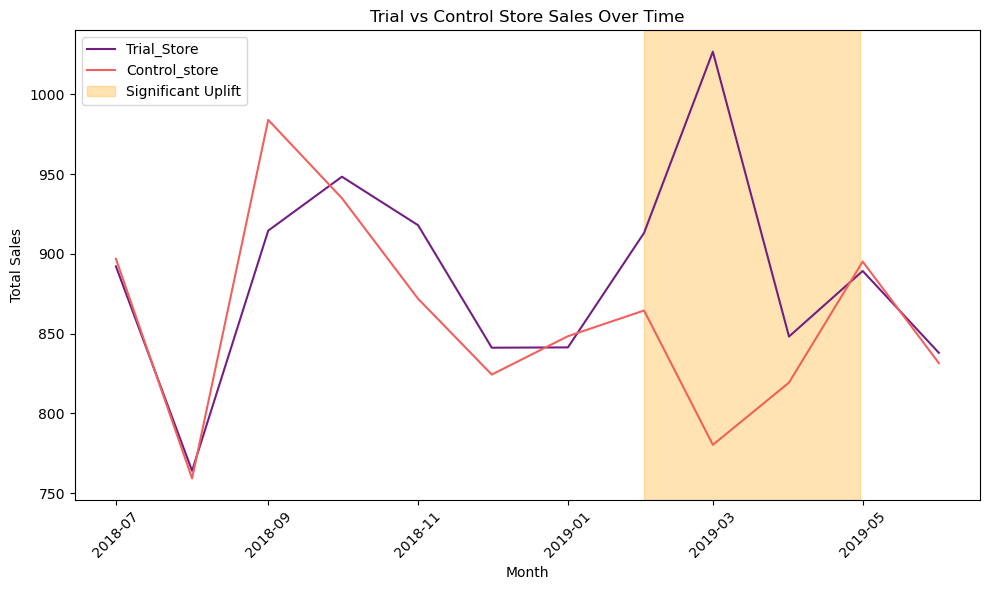

In [135]:
plt.figure(figsize =(10,6))
sns.lineplot(data = visual_86, x = 'year_month', y = 'Sales', hue = 'Store_type',palette = 'magma')
plt.axvspan(pd.to_datetime("2019-02-01"), pd.to_datetime("2019-04-30"), 
            color='orange', alpha=0.3, label='Significant Uplift')

plt.title('Trial vs Control Store Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# The trial period is highlighted by the orange strip.
 # The results show that the trial in store 86 is significantly different to its control store in the trial period as the trial store performance lies outside the 5% to 95% confidence interval of the control store in two of the three trial months.

In [ ]:
#lets look into the last trial store 88

In [ ]:
# we will call the function to see which control store matches the traits of trail store 88

In [136]:
trial_store = 88
trial_df = pre_trial_stores_metric
control_df = pre_trial_control_store

In [137]:
control_88 = find_best_control_store(trial_df, control_df, 88)

In [138]:
control_88

,Store2,scoreNSales,scoreNCust,finalControlScore
167,178,0.650803,0.707828,0.679316


# store 178 matches the traits of store 88

In [141]:
trial_88 = pre_trial_stores_metric[pre_trial_stores_metric['STORE_NBR'] == 88]

In [142]:
control_178 = pre_trial_control_store[pre_trial_control_store['STORE_NBR'] == 178]

In [143]:
trial_88

,year_month,STORE_NBR,Total_Monthly_Sales,no_of_monthly_Customers,no_of_monthly_Txn,avg_trns_per_cst
2,2018-07-01,88,1310.0,129,153,1.186047
5,2018-08-01,88,1323.8,131,158,1.206107
8,2018-09-01,88,1423.0,124,157,1.266129
11,2018-10-01,88,1352.4,123,155,1.260163
14,2018-11-01,88,1382.8,130,156,1.200000
17,2018-12-01,88,1325.2,126,148,1.174603
20,2019-01-01,88,1266.4,117,144,1.230769


In [144]:
control_178

,STORE_NBR,year_month,Total_Monthly_Sales,no_of_monthly_Customers,no_of_monthly_Txn,avg_trns_per_cust
2033,178,2018-07-01,952.0,107,131,1.224299
2034,178,2018-08-01,915.5,108,133,1.231481
2035,178,2018-09-01,954.4,101,128,1.267327
2036,178,2018-10-01,962.6,102,141,1.382353
2037,178,2018-11-01,975.6,111,138,1.243243
2038,178,2018-12-01,947.2,101,134,1.326733
2039,178,2019-01-01,837.2,95,118,1.242105


In [ ]:
#let's scale down the control sales features and call it scaled sales.

In [145]:
control_178_sum = control_178['Total_Monthly_Sales'].sum()

In [146]:
trial_88_sum = trial_88['Total_Monthly_Sales'].sum()

In [149]:
scaled_factorr = trial_88_sum/control_178_sum

In [150]:
scaled_factorr

1.4338146535258616

In [170]:
trial_88 = df_copy.copy()

In [171]:
trial_88 = trial_88[trial_88['STORE_NBR'] == 88]

In [172]:
trial_88

,year_month,STORE_NBR,Total_Monthly_Sales,no_of_monthly_Customers,no_of_monthly_Txn,avg_trns_per_cust
84,2018-07-01,88,1310.00,129,153,1.186047
348,2018-08-01,88,1323.80,131,158,1.206107
613,2018-09-01,88,1423.00,124,157,1.266129
878,2018-10-01,88,1352.40,123,155,1.260163
1142,2018-11-01,88,1382.80,130,156,1.200000
1406,2018-12-01,88,1325.20,126,148,1.174603
1668,2019-01-01,88,1266.40,117,144,1.230769
1931,2019-02-01,88,1370.20,124,153,1.233871
2195,2019-03-01,88,1477.20,134,169,1.261194
2460,2019-04-01,88,1439.40,128,162,1.265625


In [166]:
control_178 = df_copy.copy()

In [167]:
control_178 = control_178[control_178['STORE_NBR'] == 178]

In [168]:
control_178['scaled_sales'] = control_178['Total_Monthly_Sales'] * scaled_factorr.round(1)

In [169]:
control_178

,year_month,STORE_NBR,Total_Monthly_Sales,no_of_monthly_Customers,no_of_monthly_Txn,avg_trns_per_cust,scaled_sales
173,2018-07-01,178,952.0,107,131,1.224299,1332.80
437,2018-08-01,178,915.5,108,133,1.231481,1281.70
702,2018-09-01,178,954.4,101,128,1.267327,1336.16
967,2018-10-01,178,962.6,102,141,1.382353,1347.64
1231,2018-11-01,178,975.6,111,138,1.243243,1365.84
1495,2018-12-01,178,947.2,101,134,1.326733,1326.08
1756,2019-01-01,178,837.2,95,118,1.242105,1172.08
2020,2019-02-01,178,1088.8,107,145,1.355140,1524.32
2285,2019-03-01,178,998.8,114,143,1.254386,1398.32
2549,2019-04-01,178,1059.8,117,148,1.264957,1483.72


In [ ]:
#calculating the absolute percentage difference between trial and control sales.

In [ ]:
# Before calculating that we will merge the dataset.

In [173]:
merge_88 = pd.merge(trial_88[['year_month', 'Total_Monthly_Sales']], control_178[['year_month', 'scaled_sales']],
                    on = 'year_month')

In [174]:
merge_88

,year_month,Total_Monthly_Sales,scaled_sales
0,2018-07-01,1310.00,1332.80
1,2018-08-01,1323.80,1281.70
2,2018-09-01,1423.00,1336.16
3,2018-10-01,1352.40,1347.64
4,2018-11-01,1382.80,1365.84
5,2018-12-01,1325.20,1326.08
6,2019-01-01,1266.40,1172.08
7,2019-02-01,1370.20,1524.32
8,2019-03-01,1477.20,1398.32
9,2019-04-01,1439.40,1483.72


In [ ]:
#absolute percentage difference, expecting 0 difference 
#hypothesis testing - the trial store had no difference in sales during the campaign period

In [175]:
merge_88['percentage_diff'] = abs(merge_88['Total_Monthly_Sales'] - merge_88['scaled_sales'])/ merge_88['Total_Monthly_Sales']

In [176]:
merge_88

,year_month,Total_Monthly_Sales,scaled_sales,percentage_diff
0,2018-07-01,1310.00,1332.80,0.017405
1,2018-08-01,1323.80,1281.70,0.031802
2,2018-09-01,1423.00,1336.16,0.061026
3,2018-10-01,1352.40,1347.64,0.003520
4,2018-11-01,1382.80,1365.84,0.012265
5,2018-12-01,1325.20,1326.08,0.000664
6,2019-01-01,1266.40,1172.08,0.074479
7,2019-02-01,1370.20,1524.32,0.112480
8,2019-03-01,1477.20,1398.32,0.053398
9,2019-04-01,1439.40,1483.72,0.030791


In [ ]:
#let's understand the deviation 

In [178]:
std_deviation = stdev(merge_88.loc[merge_88['year_month'] < '2019-02-01', 'percentage_diff'])

In [179]:
std_deviation

0.028775127347042975

In [ ]:
#PERFORMING T-TEST TO CHECK UPLIFT
# HYPOTHESIS --> THE TRIAL STORE HAD NO SIGNIFICANT UPLIFT DURING THE CAMPAIGN PERIOD.

In [182]:
merge_88['T_VALUE'] = (merge_88['percentage_diff'] - 0) / std_deviation

In [188]:
merge_88.loc[(merge_88['year_month'] > '2019-01-01') & (merge_88['year_month'] < '2019-05-01'), 'T_VALUE']

7    3.908929
8    1.855711
9    1.070042
Name: T_VALUE, dtype: float64

In [183]:
merge_88

,year_month,Total_Monthly_Sales,scaled_sales,percentage_diff,T_VALUE
0,2018-07-01,1310.00,1332.80,0.017405,0.604848
1,2018-08-01,1323.80,1281.70,0.031802,1.105204
2,2018-09-01,1423.00,1336.16,0.061026,2.120790
3,2018-10-01,1352.40,1347.64,0.003520,0.122316
4,2018-11-01,1382.80,1365.84,0.012265,0.426235
5,2018-12-01,1325.20,1326.08,0.000664,0.023077
6,2019-01-01,1266.40,1172.08,0.074479,2.588306
7,2019-02-01,1370.20,1524.32,0.112480,3.908929
8,2019-03-01,1477.20,1398.32,0.053398,1.855711
9,2019-04-01,1439.40,1483.72,0.030791,1.070042


In [ ]:
#identifying the t-thresold to cutoff significance level.

In [185]:
t_178 = t.isf(0.05, df = 7)
print(t_178)

1.8945786050613054


In [ ]:
#IT appears as if february did see an uplift but other 2 months couldn't see much of a difference.
#to understand it visually let's visualise it.

In [189]:
visual_88 = merge_88.copy()

In [190]:
visual_88.drop(columns = {'percentage_diff', 'T_VALUE'},inplace = True)

In [193]:
visual_88.rename(columns = {'Total_Monthly_Sales' : 'Trial_store', 
                            'scaled_sales' :'Control_store'},inplace = True)

In [195]:
visual_88 = visual_88.melt(id_vars = 'year_month', value_vars= ['Trial_store', 'Control_store'],var_name = 'Store_type',
                          value_name = 'Sales')

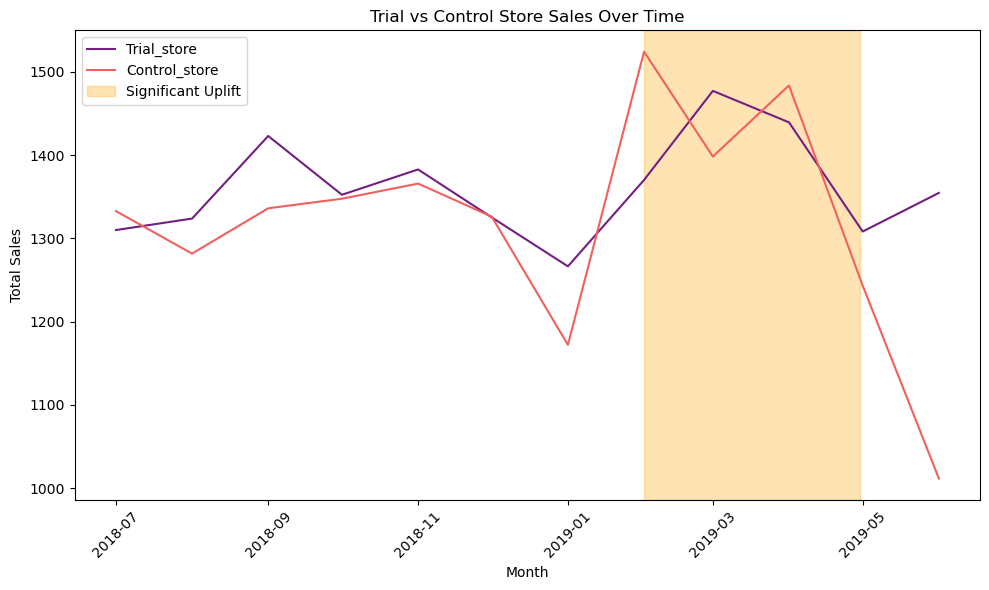

In [196]:
plt.figure(figsize =(10,6))
sns.lineplot(data = visual_88, x = 'year_month', y = 'Sales', hue = 'Store_type',palette = 'magma')
plt.axvspan(pd.to_datetime("2019-02-01"), pd.to_datetime("2019-04-30"), 
            color='orange', alpha=0.3, label='Significant Uplift')

plt.title('Trial vs Control Store Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# CONCLUSION

# OUT OF THE 3 TRIAL STORES 77 AND 86 HAD THE MOST POSITIVE EFFECT ON SALES THROUGH ITS CAMPAIGN, WHICH MADE 2 OUT OF 3 MONTHS IN WHICH THE CAMPAIGN WAS RUN, STATISTIFCALLY SIGNIFICANT.

# TRIAL STORE 88 WAS able to see uplift only for the month of february  out of february march and april. we will have to check the implementation of the campaign in that trial.

# we will now present all of this to our manager to make data driven decisions.